In [5]:
from importlib.metadata import files as importlib_files
import math
import numpy as np, matplotlib.pyplot as plt, scipy as sp
import matplotlib.image as mpimg
import torch
import time
import os, json
from datetime import datetime
import imageio.v3 as iio
from IPython.display import Image, display
from PIL import Image as PILImage
import shutil
import warnings

pi = sp.constants.pi

#from google.colab import drive, files

save_to_drive = False
#if save_to_drive:
#    print("Mounting Google Drive...")
#    drive.mount('/content/drive')

# Define simulation parameters

class SimulationManager:
    def __init__(self, **kwargs):

        self.parameters = kwargs
        self.gpe = GPEBase(**self.parameters)
        self.init_type = kwargs["init_type"]; assert self.init_type == "Gaussian" or self.init_type == "Ground State", "Given init_type is invalid. Choose either Gaussian or Ground State for init_type."
        self.device = self.gpe.device
        self.rte = None
        self.ite = None

        print("Initializing simulation with init_type:", self.init_type)
        print("Device being used:", self.device)

        if self.init_type == "Ground State":
            
            N, Np, omega = self.gpe.N, self.gpe.Np, self.gpe.omega
            filename=f"storage/ground_state_N_{N}_Np_{Np}_omega_{np.round(omega)}_includeg0_{self.gpe.include_g0}_imag_gamma_{self.parameters['imag_gamma']}".replace(".", "_") + ".pt"
            if os.path.exists(filename):
                print(f"Loading cached ground state from {filename}...")
                self.init_wf = torch.load(filename, map_location=self.device)

                self.gpe.visualizer = GPEVisualizer(
                    self.gpe.x, self.gpe.z, self.gpe.dx, self.gpe.dz, 
                    self.gpe.l, self.gpe.parameters, self.init_wf
                )

            else:
                print("Ground state not found. Running imaginary time evolution...")
                ite_init_wf = self.gpe.gaussian().to(self.device)
                self.gpe.visualizer = GPEVisualizer(self.gpe.x, self.gpe.z, self.gpe.dx, self.gpe.dz, self.gpe.l, self.gpe.parameters, ite_init_wf)
                self.ite = ImaginaryTimeGPE(self.gpe, ite_init_wf, **self.parameters)
                ground_state_wf = self.ite.imag_time_evolution()
                torch.save(ground_state_wf, filename)
                #eps = 0.002
                self.init_wf = ground_state_wf #* np.exp(1j*eps)
                self.gpe.visualizer.update_initial_state(self.init_wf)
                


        elif self.init_type == "Gaussian":
            self.init_wf = self.gpe.gaussian().to(self.device)
            self.gpe.visualizer = GPEVisualizer(self.gpe.x, self.gpe.z, self.gpe.dx, self.gpe.dz, self.gpe.l, self.gpe.parameters, self.init_wf)

        self.gpe.init_wf = self.init_wf
        
            
    def run_simulation(self):
        # Run the simulation using the GPE engine
        self.rte = RealTimeGPE(self.gpe, self.init_wf, **self.parameters)
        final_wf = self.rte.real_time_evolution()
        return final_wf

    def export_plots(self, save_to_drive=True, download_to_local=True, IN_COLAB=True):

        os.makedirs("storage", exist_ok=True)
        self.gpe.visualizer.generate_gifs()

        # Export plots and data
        source_folder = self.gpe.visualizer.base_output_dir
        zip_name = f"{source_folder}_exported"
        safe_name = os.path.basename(zip_name)
        
        # Prepend the 'storage' directory to the archive name
        archive_base_path = os.path.join("storage", safe_name)
        
        print(f"Compressing '{source_folder}' into {archive_base_path}.zip...")
        
        # 1. Compress the folder
        # Because we added "storage/" to archive_base_path, the zip goes directly there
        shutil.make_archive(archive_base_path, 'zip', source_folder)
        
        # The exact path to the newly created zip file
        zip_filepath = f"{archive_base_path}.zip"
        
        if not IN_COLAB:
            print(f"Saved locally as {zip_filepath}. Colab features disabled.")
            return

        # Only import Colab modules if we are actually in Colab
        from google.colab import drive, files

        # 2. Copy to Google Drive
        if save_to_drive:
            print("Mounting Google Drive...")
            drive.mount('/content/drive')
            
            drive_path = f'/content/drive/MyDrive/Duke/SimulationData/{safe_name}.zip'
            
            # Copy FROM the storage folder TO Google Drive
            shutil.copy(zip_filepath, drive_path)
            print(f"Success! Copied to Google Drive at: {drive_path}")
        else:
            print("Skipping Google Drive export.")

        # 3. Trigger Local Download
        if download_to_local:
            print("Triggering local download...")
            # Download directly from the storage folder
            files.download(zip_filepath)
class GPEBase():
    def __init__(self, **kwargs):
    
        hbar = sp.constants.hbar
        pi = sp.constants.pi

        if torch.cuda.is_available():
            print(f"GPU is available: {torch.cuda.get_device_name(0)}")
        else:
            print("GPU not found. Check your runtime settings.")

        self.device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
        self.high_precision = kwargs["high_precision"]


        self.debug = False
        self.time_plots = kwargs["time_plots"]
        self.final_plots = kwargs["final_plots"]
        self.plot_steps = kwargs["plot_steps"]



        if kwargs["high_precision"]:
            self.complex_type = torch.complex128
            self.real_type = torch.float64

        else:
            self.complex_type = torch.complex64
            self.real_type = torch.float32


        self.Np = kwargs["Np"]
        self.m = kwargs["m"]  #kg
        self.omega = kwargs["omega"] #Hz
        self.a0 = kwargs["a0"] #m
        self.g0 = 4*pi*hbar**2*self.a0* self.Np/self.m
        self.gamma = kwargs["gamma"]
        self.modulation_freq = kwargs["modulation freq"]
        self.modulation_amp = kwargs["modulation amplitude"]
        self.a02 = kwargs["a02"]
        self.g2 = 6*np.sqrt(5) * pi * hbar**2 * self.a02 * self.Np / self.m
        self.sigma = kwargs["sigma"]
        self.z_scale = kwargs["z_scale"]
        self.y_scale = kwargs["y_scale"]



        self.l = np.sqrt(hbar/(self.m * self.omega)) #length scale
        self.tau = 1/self.omega # time scale
        self.G0 = self.g0/(self.l**3*hbar*self.omega)
        self.G2 = self.g2/(hbar*self.omega*self.l**5)

        self.waist = kwargs["waist"]
        self.cutoff = kwargs["cutoff"]
        self.include_g0 = kwargs["include_g0"]

        self.up = kwargs["up"]
        self.N = kwargs["N"]
        self.Nz = kwargs["Nz"] if kwargs["Nz"] is not None else kwargs["N"]

        self.ev_time = kwargs["ev_time"] #s
        self.time_steps = kwargs["time_steps"]
        self.dt = self.ev_time/self.time_steps
        self.dtau = self.dt/self.tau
        self.times = np.linspace(0, self.ev_time, self.time_steps)

        self.x = torch.linspace(-self.up,self.up,self.N+1, dtype=self.real_type)[:-1]
        self.dx = (self.x[1]-self.x[0]).item(); self.dxu = self.dx/self.l
        self.z = torch.linspace(-self.up, self.up, self.Nz+1, dtype = self.real_type)[:-1]
        self.dz = (self.z[1]-self.z[0]).item(); self.dzu = self.dz/self.l

        self.X, self.Y, self.Z = torch.meshgrid(self.x,self.x,self.z, indexing='ij')
        self.uX,self.uY, self.uZ = self.X/self.l, self.Y/self.l, self.Z/self.l

        k = 2*pi*torch.fft.fftfreq(self.N, d=self.dx/self.l,  dtype=self.real_type)
        kz = 2*pi*torch.fft.fftfreq(self.Nz, d=self.dz/self.l, dtype = self.real_type)
        self.KX, self.KY, self.KZ = torch.meshgrid(k,k,kz, indexing="ij")  # Note that spacing d, is adjusted to represent spacing in uX/Y/Z
        self.K_squared = (self.KX**2 + self.KY**2 + self.KZ**2)
        self.quadrupole_multiplier = ((1/3)*self.K_squared - self.KZ**2).to(self.device)
        self.K_squared = self.K_squared.to(self.device)
        

        self.cutoff_coeff = kwargs["cutoff_coeff"]
        self.k_cutoff = pi/self.dx * (self.cutoff_coeff) #m^-1

        if self.a02 == 0:
            self.elastic_term = False

        else: self.elastic_term = True


        self.init_wf = self.gaussian().to(self.device)
        self.n0 = torch.max(torch.abs(self.init_wf*self.l**(-3/2))**2).item() * self.Np
        self.healing_length = 1/np.sqrt(8*pi*self.n0*self.a0)

        self.N_0 = self.n0 * self.l**3

        self.params()

        self.validate_parameters()

        self.visualizer = None


        if self.cutoff == "Hard Cutoff":

            k2 = self.K_squared
            unitless_k = (self.k_cutoff * self.l)**2

            self.mask = (k2 < (self.k_cutoff*self.l)**2).to(self.device)

        elif self.cutoff == "Cylinder Cutoff":

            k2 = self.K_squared
            unitless_k = (self.k_cutoff * self.l)**2

            rho2 = self.KX**2+self.KY**2
            self.mask = ((rho2 < unitless_k) & (self.KZ**2 < unitless_k)).to(self.device)

        elif self.cutoff == "Soft Cutoff":

            self.K_mag = torch.sqrt(self.KX**2 + self.KY**2 + self.KZ**2)
            self.sig = self.soft_cutoff()

        elif self.cutoff == "No Cutoff":

            self.mask = 1

        elif self.cutoff == "Manual":


            k2 = self.K_squared
            unitless_k = (10e6 * self.l)

            self.mask = (k2 < (unitless_k)**2).to(self.device)


            '''rho_k2 = self.KX**2 + self.KY**2
                        rho_cutoff = torch.max(rho_k2)
                        mask_rho = (rho_k2 < (1/3)**2 * rho_cutoff)
            
                        z_k2 = self.KZ**2
                        z_cutoff = torch.max(z_k2)
                        mask_z = (z_k2 < (1/3)**2 * z_cutoff)'''

            #raise NotImplementedError("No Manual Cutoff specified.")

        if self.modulation_freq is None:

            print("Modulation frequency not provided. Calculating modulation frequency based on dispersion relation...")

            modulation_mode = 1
            dispersion_relation_squared = (1/2) * modulation_mode ** 2 * ((1/2) * modulation_mode ** 2 + 2  * self.N_0 * (self.G0 - (2/3) * self.G2 * modulation_mode **2))

            assert dispersion_relation_squared > 0, "Dispersion relation squared is negative. Check parameters."

            self.modulation_freq = 2 * np.sqrt(dispersion_relation_squared)

            print(f"Calculated modulation frequency: {self.modulation_freq:.4f} (unitless)")



        self.parameters = {
            "Np": self.Np,
            "m": self.m,
            "omega": self.omega,
            "a0": self.a0,
            "g0": self.g0,
            "gamma": self.gamma,
            "mod freq": self.modulation_freq,
            "mod amp": self.modulation_amp,
            "a02": self.a02,
            "g2": self.g2,
            "sigma": self.sigma,
            "Box Length": self.up*2,
            "Gaussian Z-Scale: ": self.z_scale,
            "Gaussian Y-Scale: ": self.y_scale,
            "N": self.N,
            "Nz": self.Nz,
            "ev_time": self.ev_time,
            "time_steps": self.time_steps,
            "dt": self.dt,
            "dtau": self.dtau,
            "dx": self.dx,
            "dxu": self.dxu,
            "dz": self.dz,
            "dzu": self.dzu,
            "up": self.up,
            "healing_length": self.healing_length,
            "cutoff_coeff": self.cutoff_coeff,
            "cutoff": self.cutoff,
            "include_g0": self.include_g0,
            "high_precision": self.high_precision,
            "G0": self.G0,
            "G2": self.G2,
            "l": self.l,
            "tau": self.tau,
            "Peak Density": self.n0,
            "Nondimensionalized Peak Density": self.N_0,
            "Gas Parameter": self.n0 * self.a0**3
        }        


    def dprint(self, *args):
            if self.debug:
                print(*args)

    def validate_parameters(self):
        assert all(v > 0 and isinstance(v, int) for v in (self.N, self.time_steps)), "One of N, time_steps is not positive. They should all be positive."
        assert all(v > 0 and isinstance(v, float) for v in (self.omega, self.ev_time, self.plot_steps)), "One of omega, ev_time, plot_steps is not positive. They should all be positive."
        assert 1e-9 < self.l < 1e-3, "Harmonic oscillator length scale might be physically invalid."
        assert 0.1 < self.sigma/self.l < 10, "Gaussian sigma not on scale of harmonic oscillator length scale"
        #assert self.up > 4*self.sigma
        if self.healing_length/self.dx > 2: warnings.warn("dx is not smaller than 1/2 * healing length?")
        assert 1e-27 < self.m < 1e-24
        assert self.cutoff in ["Hard Cutoff", "Cylinder Cutoff", "Soft Cutoff", "No Cutoff", "Manual"],"Chosen cutoff is not valid."
        if self.device == "cuda": assert torch.cuda.is_available(), "GPU not available. Cannot request cuda."
        assert self.dtau * self.K_squared.max().item() / 2 < np.pi, "Phase accumulated per kinetic energy step is too high."
        assert isinstance(self.include_g0, bool), "include_go not boolean value"
        #Add memory check

        try: 
            int(1/self.plot_steps)
            int(1/self.plot_steps * self.time_steps)
        except:
            raise ValueError("1/plot_steps is not an integer OR 1/plot_steps * time_steps is not an integer")
        

    def params(self):
        print("-- Simulation Parameters --")
        print("Number of particles:", self.Np)
        print("Mass (kg):", self.m)
        print("Trap frequency (Hz):", self.omega)
        print("Gamma: ", self.gamma)
        print("Modulation Frequency: ", self.modulation_freq)
        print("Modulation Amplitude: ", self.modulation_amp)
        print("Scattering length a0 (m):", self.a0)
        print("Scattering length a02 (m^3):", self.a02)
        print("Sigma: ", self.sigma)
        print("Include g0: ", self.include_g0)
        print("g2/g0:", self.g2/self.g0)
        print("g0:", self.g0)
        print("g2:", self.g2)
        print("G0:", self.G0)
        print("G2:", self.G2)
        print("Box Length (m):", self.up*2)
        print("length scale", self.l)
        print("Evolution time (s):", self.ev_time)
        print("Time steps: ", self.time_steps)
        print("dt: ", self.dt)
        print("dtau = dt/tau: ", self.dtau)
        print("Unitless Time (time/tau): ", self.ev_time/self.tau)
        print("Number of 1D grid points: ", self.N)
        print("dx:", self.dx)
        print("dz: ", self.dz)
        print("Healing length (m):", self.healing_length)
        print("dx/healing length:", self.dx/self.healing_length)
        print("dz/healing length:", self.dz/self.healing_length)
        print("up/healing length: ", self.up / self.healing_length)
        print("cutoff coeff:", self.cutoff_coeff)
        print("Cutoff Type: ", self.cutoff)
        print("K_Max: ", self.KX.max().item())
        print("Particle Density: ", self.n0)
        print("Nondimensionalized Peak Density: ", self.N_0)
        print("na0^3: ", self.n0 * self.a0**3)

    def norm(self, f):
        mag = torch.sum(torch.abs(f)**2) * self.dx**2 * self.dz
        return mag.item()

    def unitless_norm(self,f):
        mag = torch.sum(torch.abs(f)**2) * self.dxu**2 * self.dzu
        return mag.item()

    def gaussian(self):
        sigma = self.sigma
        x, y, z = self.X, self.Y, self.Z
        ys, zs = self.y_scale, self.z_scale
        gaussian = torch.exp(-1*(x**2+(ys * y)**2+(zs * z)**2)/(2*sigma**2)).to(self.complex_type) # Gaussian ansatz exp(r^2/2sigma^2)
        norm = self.norm(gaussian)
        gaussian *= (1/norm)**(1/2)

        #Nondimensionalization
        gaussian = (gaussian * self.l**(3/2)).to(self.complex_type)
        return gaussian
    
    def soft_cutoff(self):
    
            kc = self.k_cutoff * self.l
            delta_k = 0.1 * kc  # Unitless smearing width
    
            K_mag = self.K_mag
    
            #exponent = torch.clip((K_mag - kc)/delta_k, -700, 700)
    
            #sig = 1/(1+torch.exp(exponent))
    
            sig = torch.sigmoid(-(K_mag - kc)/delta_k)
    
            return sig
    
        # Define operators
    
    def trap_potential(self, gamma, unitless_t=0.0, modulation_amp=0.0, modulation_freq=0.0):
        x,y,z = self.uX, self.uY, self.uZ

        base_pot = (1/2)*(x**2+y**2+gamma**2*z**2) # Non-dimensionalized potential; Note that factor of i–it's built into the function'''

        return base_pot * (1.0 + modulation_amp * math.sin(modulation_freq*unitless_t))**2
        

    def g0_term(self, psi): # in position basis
        return self.G0 * torch.abs(psi)**2


    def kinetic_energy(self):
        return (1/2) * self.K_squared # KE already in momentum space

    def quadrupole_term(self, psi):

        psi_mag_fft = torch.fft.fftn(torch.abs(psi)**2)
        op = psi_mag_fft * self.quadrupole_multiplier

        if self.cutoff in ["Hard Cutoff", "Cylinder Cutoff", "Manual", "No Cutoff"]:
            op *= self.mask
        elif self.cutoff == "Soft Cutoff":
            op *= self.sig
        else:
            raise ValueError("Invalid cutoff type. Choose from 'Hard Cutoff', 'Cylinder Cutoff', 'Soft Cutoff', or 'No Cutoff'.")

        return self.G2 * torch.real(torch.fft.ifftn(op))


    #@torch.compile
    def single_loop(self, wf, exp_potential_step, exp_KE_step, dtau, imaginary = False):

        phase = -1 if imaginary else -1j

        wf *= exp_potential_step

        if self.elastic_term:
            q1 = self.quadrupole_term(wf)
            #print("q1 min/max:", q1.min().item(), q1.max().item())

        else: q1 = 0

        first_g0 = self.g0_term(wf) if self.include_g0 else 0

        exponent1 = torch.clip(phase *(first_g0 + q1) * (dtau/2), min=-50, max=50) if imaginary else phase *(first_g0 + q1) * (dtau/2)

        wf *= torch.exp(exponent1)

        g2_energy = 0.5 * torch.sum(q1 * torch.abs(wf)**2) * self.dxu**2 * self.dzu
        g0_energy = 0.5 * torch.sum(first_g0 * torch.abs(wf)**2) * self.dxu**2 * self.dzu if self.include_g0 else torch.zeros(1, device=self.device, dtype = self.real_type)
        pot = torch.sum(self.potential_step * torch.abs(wf)**2) * self.dxu**2 * self.dzu


        # Apply momentum-basis operators for interval dt

        torch.zeros(1, device=wf.device, dtype=wf.real.dtype)

        wf = torch.fft.fftn(wf)

        # index corresponds to kx = 0, ky = 0
        # detached from computational graph, but keeps on GPU
        kx_amps = torch.fft.fftshift(torch.abs(wf[:,0,0])).detach()
        kz_amps = torch.fft.fftshift(torch.abs(wf[0,0,:])).detach()

        wf *= exp_KE_step

        KE_energy = torch.sum(self.KE_step * torch.abs(wf)**2) * self.dxu**2 * self.dzu/self.N**3

        wf = torch.fft.ifftn(wf)

        # Apply position-basis operators for interval dt/2

        wf *= exp_potential_step

        if self.elastic_term:
            q2 = self.quadrupole_term(wf)

        else: q2 = 0

        second_g0 = self.g0_term(wf) if self.include_g0 else torch.zeros(1, device=self.device, dtype = self.real_type)

        exponent2 = torch.clip(phase*(second_g0 + q2) * (dtau/2), min=-50, max=50) if imaginary else phase*(second_g0 + q2) * (dtau/2)
        wf *= torch.exp(exponent2)

        energy_tuple = (KE_energy, pot, g0_energy, g2_energy, KE_energy+pot+g0_energy+g2_energy)

        return wf, energy_tuple, (kx_amps, kz_amps)

class RealTimeGPE():
    def __init__(self, basegpe: GPEBase, init_wf, **kwargs):

        self.init_wf = init_wf
        self.basegpe = basegpe
        self.gamma = kwargs["gamma"]
        self.ev_time = kwargs["ev_time"]
        self.time_steps = kwargs["time_steps"]
        self.dt = self.ev_time / self.time_steps
        self.times = np.linspace(0, self.ev_time, self.time_steps)
        self.tau = self.basegpe.tau
        self.dtau = self.dt / self.tau
        
        self.waist = kwargs["waist"]
        self.plot_steps = kwargs["plot_steps"]
        self.uX, self.uY, self.uZ = basegpe.uX, basegpe.uY, basegpe.uZ
        self.dxu = basegpe.dxu
        self.dzu = basegpe.dzu

        self.device = basegpe.device
        
        self.time_plots = kwargs["time_plots"]


    def real_time_evolution(self):
        wf = self.init_wf # Start with the provided ground state
        time_steps = self.time_steps
        dt = self.dt; dxu = self.dxu; dzu = self.dzu
        uX, uY, uZ = self.uX, self.uY, self.uZ
        
        # Prepare operators (Multiplier is -1j for real time)
        pot_multiplier = -1j

        KE_op = self.basegpe.kinetic_energy().to(self.device)
        exp_KE = torch.exp(pot_multiplier * KE_op * self.dtau).to(self.device)
        self.basegpe.KE_step = KE_op

        self.energies = []
        waist_tracker = []; uR2 = (uX**2+uY**2+uZ**2).to(self.device)
        self.kx_tracker = []
        self.kz_tracker = []
        
        og_start_time = time.perf_counter()
        start_time = time.perf_counter()

        mod_amp = self.basegpe.modulation_amp
        mod_freq = self.basegpe.modulation_freq
        
        for i in range(time_steps):

            t_current = i * self.dtau
            current_potential = self.basegpe.trap_potential(self.gamma, unitless_t = t_current, modulation_amp=mod_amp, modulation_freq = mod_freq).to(self.device)
            self.basegpe.potential_step = current_potential
            exp_potential = torch.exp(pot_multiplier * current_potential * (self.dtau / 2)).to(self.device)

            if i == 1 and self.device.type == "cuda":
                torch.cuda.reset_peak_memory_stats()

            wf, energy_tuple, amps = self.basegpe.single_loop(wf, exp_potential, exp_KE, self.dtau)

            self.kx_tracker.append(amps[0])
            self.kz_tracker.append(amps[1])

            self.energies.append([e.real.item() for e in energy_tuple])

            if (i % (time_steps* self.plot_steps) == 0 and i > 0) or (i == time_steps-1):
                    print("Roughly {}% done".format(i/time_steps*100))
                    print("Elapsed time: {:.2f} minutes".format((time.perf_counter()-start_time)/60))
                    start_time = time.perf_counter()

                    self.t = str(np.round(i * dt*1000, decimals=1)).replace(".", "_")
                    self.index = i
                    #if self.time_plots: self.basegpe.visualizer.save_plots(wf, self.t, self.index)

            if self.waist: waist_tracker.append((torch.sum(torch.abs(wf)**2 * uR2)*dxu**2*dzu).cpu().item())

            if i == 1 and self.device.type == "cuda":
                torch.cuda.synchronize()
                peak_bytes = torch.cuda.max_memory_allocated()
                print(f"Peak GPU memory for N={self.basegpe.N}: {peak_bytes / 1e9:.2f} GB")

        print(f"Total time: {(time.perf_counter()-og_start_time)/60} min")

        if self.waist: waist_tracker = np.array(waist_tracker) * self.basegpe.l**2; self.waist_array = waist_tracker

        #We take the mode amplitude slices and put each of them (one for each time step) on CPU
        #Note that these are all tensors that stay on GPU and take up GPU VRAM until this point
        #Given N = 400 and 10,000 timesteps, the VRAM takes is nontrivial, if scaling up, considering moving each one to CPU as you go
        #Note that takes extra time, though
        #If we did it with N = 400 and 10,000 timesteps, it would take longer and isn't worth it for the VRAM your saving (in the tens of MB which is nothing when VRAM is in several GB)

        kx_data = torch.stack(self.kx_tracker).cpu().numpy()
        kz_data = torch.stack(self.kz_tracker).cpu().numpy()
        mode_data = (kx_data, kz_data)

        #self.basegpe.visualizer.save_final_plots((self.waist, waist_tracker), self.energies, self.basegpe.times, self.dt, self.tau, mode_data)

        print("Final WF normalization", self.basegpe.unitless_norm(wf))

        return wf

class ImaginaryTimeGPE():
    def __init__(self, basegpe: GPEBase, init_wf, **kwargs):
        
        # Imaginary time specific parameters
        self.imag_dtau = kwargs["imag_dtau"]
        self.max_steps = kwargs["imag_max_steps"]
        self.tolerance = kwargs["tolerance"]; assert self.tolerance > 0, "Positive tolerance required."
        self.imag_gamma = kwargs["imag_gamma"] # Enforced isotropic trap for ground state search
        self.basegpe = basegpe
        self.init_wf = init_wf
        self.device = self.basegpe.device

        self.uX, self.uY, self.uZ = basegpe.uX, basegpe.uY, basegpe.uZ

    def imag_time_evolution(self):
        print("Finding ground state via imaginary time...")
        wf = self.init_wf #self.basegpe.gaussian().to(self.device)

        print("Imaginary Time Evolution Parameters:")
        print(f"  dtau: {self.imag_dtau}")
        print(f"  max_steps: {self.max_steps}")
        print(f"  tolerance: {self.tolerance}")

        # Prepare operators (Multiplier is -1 for imaginary time)
        pot_multiplier = -1 

        pot_term = self.basegpe.trap_potential(gamma=self.imag_gamma).to(self.device)
        KE_term = self.basegpe.kinetic_energy().to(self.device)
        
        exp_potential = torch.exp(pot_multiplier * pot_term * (self.imag_dtau / 2)).to(self.device)
        exp_KE = torch.exp(pot_multiplier * KE_term * self.imag_dtau).to(self.device)

        self.basegpe.potential_step = pot_term
        self.basegpe.KE_step = KE_term
        
        previous_energy = float('inf'); self.energies = []
        og_start_time = time.perf_counter()
        
        for i in range(self.max_steps):
            wf, energy_tuple, _ = self.basegpe.single_loop(wf, exp_potential, exp_KE, self.imag_dtau, imaginary=True)
            
            # Renormalize (Crucial for imaginary time!)
            mag = self.basegpe.unitless_norm(wf)
            #if not 0.5 < mag < 1.5: print(mag)
            wf *= (1 / mag)**(1 / 2)
            
            # Check convergence
            current_energy = energy_tuple[-1].real.item()
            self.energies.append([e.real.item() for e in energy_tuple])
            if i % 100 == 0 and i > 0:
                print("Step: {:d}, Current Energy: {:.6f}, Change: {:.6e}".format(int(i), current_energy, abs(current_energy - previous_energy)/previous_energy))
                print("Elapsed time: {:.2f} minutes".format((time.perf_counter()-og_start_time)/60))
                if abs(current_energy - previous_energy)/previous_energy < self.tolerance:
                    print(f"Converged at step {i} with Energy {current_energy:.6f}")
                    print(f"Total time: {(time.perf_counter()-og_start_time)/60} min")
                    break
                previous_energy = current_energy

        #self.basegpe.visualizer.imaginary_final_plots(self.energies, time_array=np.linspace(0, len(self.energies)*self.imag_dtau, len(self.energies), endpoint=False))
                
        return wf

class GPEVisualizer:
    def __init__(self, x, z, dx, dz, l, parameters: dict, init_wf, base_dir_name=""):
        # 1. Bring in the static PyTorch tensors and immediately convert to NumPy
        self.x = x.cpu().numpy()
        self.z = z.cpu().numpy()
        self.dx = dx
        self.dz = dz
        self.l = l
        self.parameters = parameters
        self.waist = self.parameters.get("waist", False)
        
        # 2. Pre-calculate the meshgrids ONCE
        self.pX1, self.pY = np.meshgrid(self.x, self.x, indexing='ij')
        self.pX2, self.pZ = np.meshgrid(self.x, self.z, indexing='ij')
        
        # 3. Setup directories (moved from your old set_directory method)
        self.set_directory(base_dir_name)

        self.init_wf = init_wf.cpu().numpy()
        #initial_xy_density = np.sum(np.abs(init_psi)**2 * dz, axis=2)
        self.u_initial_xy_density = np.sum(np.abs(self.init_wf)**2 * dz/l, axis=2)


    def update_initial_state(self, init_wf):
        if isinstance(init_wf, torch.Tensor):
            self.init_wf = init_wf.detach().cpu().numpy()
        else:
            self.init_wf = np.array(init_wf)

        self.u_initial_xy_density = np.sum(np.abs(self.init_wf)**2 * self.dz/self.l, axis=2)

    def set_directory(self, name=""):

      self.timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")

      self.base_output_dir = os.path.join("storage", f"{name}simulation_data_{self.timestamp}")
      os.makedirs(self.base_output_dir, exist_ok=True)

      subfolders = ["XY Density", "XY and Initial Density", "XZ Density", "X Slice", "Y Slice", "Z Slice"]
      self.folder_paths = {}

      for folder in subfolders:
          path = os.path.join(self.base_output_dir, folder)
          os.makedirs(path, exist_ok=True)
          self.folder_paths[folder] = path  # Stores paths for easy access later

      # 2. Save the parameters as a JSON file inside the run folder
      param_filepath = os.path.join(self.base_output_dir, "global_parameters.json")
      with open(param_filepath, "w") as json_file:
          json.dump(self.parameters, json_file, indent=4)


    def save_plots(self, wf, time, index):
    
          # , folder_name = "Breathing Mode Data"
    
          """run_dir = os.path.join(self.base_output_dir, folder_name)
          os.makedirs(run_dir, exist_ok=True)"""
    
          xy_density_path = self.folder_paths["XY Density"]
          xy_init_density_path = self.folder_paths["XY and Initial Density"]
          xz_density_path = self.folder_paths["XZ Density"]
          x_slice_path = self.folder_paths["X Slice"]
          y_slice_path = self.folder_paths["Y Slice"]
          z_slice_path = self.folder_paths["Z Slice"]
    
          pX1, pY = self.pX1, self.pY
          pX2, pZ = self.pX2, self.pZ
    
          dx, dz, l = self.dx, self.dz, self.l
    
          current_wf = wf.cpu().numpy()
          uxy_density = np.sum(np.abs(current_wf)**2 * dz/l, axis=2)
          uxz_density = np.sum(np.abs(current_wf)**2 * dx/l, axis=1)
    
    
    
          fig1, ax1 = plt.subplots()
          ax1.set_aspect('equal', 'box')
          im1 = ax1.pcolormesh(pX1/l, pY/l, uxy_density)
          ax1.set_title(f"XY Density at Time t = {time} ms")
          ax1.set_xlabel("Unitless Distance (X)")
          ax1.set_ylabel("Unitless Distance (Y)")
          fig1.colorbar(im1, ax=ax1, label="Normalized Density")
          ax1.grid(True, alpha=0.4)
          fig1.tight_layout()
          fig1.savefig(os.path.join(xy_density_path, f"XY_Density_{index:05d}.png"), dpi=300)
          plt.close(fig1) # Free memory
    
    
          ### Next Plot
    
          fig2, (ax2, ax3) = plt.subplots(2, 1, figsize=(8, 8), sharex=True) #, ax3, ax4, ax5
          ax2.set_aspect('equal', 'box')
          ax3.set_aspect('equal', 'box')
    
          scale_max = max(np.max(self.u_initial_xy_density),np.max(uxy_density))
    
          im2 = ax2.pcolormesh(pX1/l, pY/l, uxy_density, vmin=0, vmax=scale_max)
          ax2.set_title(f"XY Density at Time t = {time} ms")
          fig2.colorbar(im2, ax=ax2, label="Density")
          ax2.grid(True, alpha=0.4)
    
          im3 = ax3.pcolormesh(pX1/l, pY/l, self.u_initial_xy_density, vmin=0, vmax=scale_max)
          ax3.set_title("Initial XY Density")
          fig2.colorbar(im3, ax=ax3, label="Density")
          ax3.grid(True, alpha=0.4)
    
          fig2.tight_layout()
          fig2.savefig(os.path.join(xy_init_density_path, f"Initial_and_Evolved_XY_Density_{index:05d}.png"), dpi=300, bbox_inches="tight")
          plt.close(fig2)
    
          ### Next Plot
    
          fig5, ax5 = plt.subplots()
          ax5.set_aspect('equal', 'box')
          im5 = ax5.pcolormesh(pX2/l, pZ/l, uxz_density)
          ax5.set_title(f"XZDensity t = {time} ms")
          ax5.set_xlabel("Unitless Distance (X)")
          ax5.set_ylabel("Unitless Distance (Z)")
          fig5.colorbar(im5, ax=ax5, label="Normalized Density")
          ax5.grid(True, alpha=0.4)
          fig5.tight_layout()
          fig5.savefig(os.path.join(xz_density_path, f"XZ_Density_{index:05d}.png"), dpi=300)
          plt.close(fig5)
    
          ## Next plot
    
          fig6, ax6 = plt.subplots()
          ax6.set_aspect('equal', 'box')
          x_mid = current_wf.shape[0] // 2
          im6 = ax6.pcolormesh(pX2/l, pZ/l, np.abs(current_wf[x_mid,:,:])**2)
          ax6.set_title(f"Density Slice at x=0 at Time t = {time} ms")
          ax6.set_xlabel("Unitless Distance (Y)")
          ax6.set_ylabel("Unitless Distance (Z)")
          fig6.colorbar(im6, ax=ax6, label = "Normalized Density")
          ax6.grid(True, alpha=0.4)
          fig6.tight_layout()
          fig6.savefig(os.path.join(x_slice_path, f"DensitySliceX_{index:05d}.png"), dpi=300)
          plt.close(fig6)
    
          ## Next Plot
    
          fig7, ax7 = plt.subplots()
          ax7.set_aspect('equal', 'box')
          y_mid = current_wf.shape[1] // 2
          im7 = ax7.pcolormesh(pX2/l, pZ/l, np.abs(current_wf[:,y_mid,:])**2)
          ax7.set_title(f"Density Slice at y=0 at Time t = {time} ms")
          ax7.set_xlabel("Unitless Distance (X)")
          ax7.set_ylabel("Unitless Distance (Z)")
          fig7.colorbar(im7, ax=ax7, label = "Normalized Density")
          ax7.grid(True, alpha=0.4)
          fig7.tight_layout()
    
          fig7.savefig(os.path.join(y_slice_path, f"DensitySliceY_{index:05d}.png"), dpi=300)
          plt.close(fig7)
    
          ### Next Plot
    
          fig4, ax4 = plt.subplots()
          ax4.set_aspect('equal', 'box')
          z_mid = current_wf.shape[2] // 2
          im4 = ax4.pcolormesh(pX1/l, pY/l, np.abs(current_wf[:,:,z_mid])**2)
          ax4.set_title(f"Density Slice at z=0 at Time t = {time} ms")
          ax4.set_xlabel("Unitless Distance (X)")
          ax4.set_ylabel("Unitless Distance (Y)")
          fig4.colorbar(im4, ax=ax4, label="Normalized Density")
          ax4.grid(True, alpha=0.4)
          fig4.tight_layout()
    
          fig4.savefig(os.path.join(z_slice_path, f"DensitySliceZ_{index:05d}.png"), dpi=300)
          plt.close(fig4)
    
    
    def save_final_plots(self, waist:tuple, energies:tuple, time_array:np.ndarray, dt:float, tau:float, mode_data=None):

        waist_bool = waist[0]
        if waist[0] == True:
            waist_array = waist[1]

        os.makedirs(self.base_output_dir, exist_ok=True) # Just in case, make data folder

        final_plots_filepath = os.path.join(self.base_output_dir, "Summary Plots") # Make path for folder for following plots
        self.folder_paths["Summary Plots"] = final_plots_filepath
        os.makedirs(final_plots_filepath, exist_ok=True) # Make folder

        # Energy contribution plot
        fig, ax = plt.subplots()

        ax.plot(time_array, energies)
        ax.set_xlabel("Time (s)")
        ax.set_ylabel("Energy (Unitless)")
        ax.set_title("Energy Contributions vs Time")
        ax.legend(["Kinetic Energy", "Potential", "g0 Term", "g2 Term", "Total"])
        fig.text(0.5, 0.01, f"Note: dt/tau = {dt/tau}. Only if this small will total energy be conserved.",
            ha="center", fontsize=10, wrap=True)

        ax.grid(True, alpha=0.4)

            # Adjust padding so the caption is not cut off
        fig.tight_layout()
        fig.subplots_adjust(bottom=0.15)


        fig.savefig(os.path.join(final_plots_filepath, "Energy Contributions.png"), dpi=300)
        plt.close(fig)

        # Waist plot

        if waist_bool:

            plt.plot(time_array, waist_array)
            plt.xlabel("Time (s)")
            plt.ylabel("Waist (m)")
            plt.title("BEC Waist vs. Time")
            plt.grid(True, alpha=0.4)
            plt.tight_layout()
            plt.savefig(os.path.join(final_plots_filepath, "Waist vs Time.png"), dpi=300)
            plt.close()


        # Initial Density Plot

        init_psi = self.init_wf
        #initial_xy_density = np.sum(np.abs(init_psi)**2 * self.dz, axis=2)
        u_initial_xy_density = np.sum(np.abs(init_psi)**2 * self.dz/self.l, axis=2)

        #initial_xz_density = np.sum(np.abs(init_psi)**2 * self.dx, axis=1)
        u_initial_xz_density = np.sum(np.abs(init_psi)**2 * self.dx/self.l, axis=1)

        #initial_yz_density = np.sum(np.abs(init_psi)**2 * self.dx, axis=0)
        u_initial_yz_density = np.sum(np.abs(init_psi)**2 * self.dx/self.l, axis=0)

        pX, pY = self.pX1, self.pY

        fig1, ax1 = plt.subplots()
        ax1.set_aspect('equal', 'box')
        im1 = ax1.pcolormesh(pX/self.l, pY/self.l, u_initial_xy_density)
        ax1.set_title("Initial XY Density")
        ax1.set_xlabel("Unitless Distance (X)")
        ax1.set_ylabel("Unitless Distance (Y)")
        fig1.colorbar(im1, ax=ax1, label="Normalized Density")
        ax1.grid(True, alpha=0.4)
        fig1.tight_layout()
        fig1.savefig(os.path.join(final_plots_filepath,"Initial XY Density.png"), dpi=300)
        plt.close(fig1)

        pX, pZ = self.pX2, self.pZ

        fig1, ax1 = plt.subplots()
        ax1.set_aspect('equal', 'box')
        im1 = ax1.pcolormesh(pX/self.l, pZ/self.l, u_initial_xz_density)
        ax1.set_title("Initial XZ Density")
        ax1.set_xlabel("Unitless Distance (X)")
        ax1.set_ylabel("Unitless Distance (Z)")
        fig1.colorbar(im1, ax=ax1, label="Normalized Density")
        ax1.grid(True, alpha=0.4)
        fig1.tight_layout()
        fig1.savefig(os.path.join(final_plots_filepath,"Initial XZ Density.png"), dpi=300)
        plt.close(fig1)

        fig1, ax1 = plt.subplots()
        ax1.set_aspect('equal', 'box')
        im1 = ax1.pcolormesh(pX/self.l, pZ/self.l, u_initial_yz_density)
        ax1.set_title("Initial YZ Density")
        ax1.set_xlabel("Unitless Distance (Y)")
        ax1.set_ylabel("Unitless Distance (Z)")
        fig1.colorbar(im1, ax=ax1, label="Normalized Density")
        ax1.grid(True, alpha=0.4)
        fig1.tight_layout()
        fig1.savefig(os.path.join(final_plots_filepath,"Initial YZ Density.png"), dpi=300)
        plt.close(fig1)

        if mode_data is not None:

            from matplotlib.colors import LogNorm

            kx_data, kz_data = mode_data

            # Reconstruct the shifted momentum axes for plotting
            k_x_axis = np.fft.fftshift(np.fft.fftfreq(self.parameters["N"], d=self.parameters["dxu"])) * 2 * np.pi
            k_z_axis = np.fft.fftshift(np.fft.fftfreq(self.parameters["Nz"], d=self.parameters["dzu"])) * 2 * np.pi

            fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5), sharey=True)

            # Define a dynamic log scale:
            # vmin sets the noise floor (e.g., 1e-10). Anything smaller is clipped to avoid log(0) errors.
            # vmax scales automatically to the peak condensate density at k=0.
            noise_floor = 1e-10
            kx_max = max(np.max(kx_data), noise_floor * 10)
            kz_max = max(np.max(kz_data), noise_floor * 10)

            print("Max Kx Amplitude:", kx_max)
            print("Max Kz Amplitude:", kz_max)

            norm_kx = LogNorm(vmin=noise_floor, vmax=kx_max)
            norm_kz = LogNorm(vmin=noise_floor, vmax=kz_max)

            # Plot Kx Amplitudes with LogNorm
            im1 = ax1.pcolormesh(k_x_axis, time_array, kx_data, shading='auto', cmap='magma', norm=norm_kx)
            ax1.set_title("K_x Mode Amplitudes vs Time (Log Scale)")
            ax1.set_xlabel("Unitless Momentum (k_x)")
            ax1.set_ylabel("Time (s)")
            fig.colorbar(im1, ax=ax1, label="Log(Amplitude)")

            # Plot Kz Amplitudes with LogNorm
            im2 = ax2.pcolormesh(k_z_axis, time_array, kz_data, shading='auto', cmap='magma', norm=norm_kz)
            ax2.set_title("K_z Mode Amplitudes vs Time (Log Scale)")
            ax2.set_xlabel("Unitless Momentum (k_z)")
            fig.colorbar(im2, ax=ax2, label="Log(Amplitude)")

            fig.tight_layout()
            fig.savefig(os.path.join(final_plots_filepath, "Mode_Amplitudes_vs_Time.png"), dpi=300)
            plt.close(fig)



    def imaginary_final_plots(self, energies:tuple, time_array:np.ndarray):

        os.makedirs(self.base_output_dir, exist_ok=True) # Just in case, make data folder
        
        final_plots_filepath = os.path.join(self.base_output_dir, "Imaginary Time Evolution Plots") # Make path for folder for following plots
        self.folder_paths["Imaginary Time Evolution Plots"] = final_plots_filepath
        os.makedirs(final_plots_filepath, exist_ok=True) # Make folder

        # Energy contribution plot
        fig, ax = plt.subplots()

        ax.plot(time_array, energies)
        ax.set_xlabel("Time (s)")
        ax.set_ylabel("Energy (Unitless)")
        ax.set_title("Energy Contributions vs Time (ITE)")
        ax.legend(["Kinetic Energy", "Potential", "g0 Term", "g2 Term", "Total"])

        ax.grid(True, alpha=0.4)

            # Adjust padding so the caption is not cut off
        fig.tight_layout()
        fig.subplots_adjust(bottom=0.15)


        fig.savefig(os.path.join(final_plots_filepath, "Energy Contributions.png"), dpi=300)
        plt.close(fig)

    def generate_gifs(self, duration_ms=200):
        import glob

        print("Generating GIFs for all subfolders...")
        
        # Walk through the main output directory and all its subfolders
        for root, dirs, files in os.walk(self.base_output_dir):
            
            # 1. Grab and sort all zero-padded PNGs in the current folder
            png_files = sorted(glob.glob(os.path.join(root, "*.png")))
            
            if not png_files:
                continue
                
            name = os.path.basename(root).replace(" ", "_")

            if name == "Summary_Plots" or name == "Imaginary_Time_Evolution_Plots":
                continue

            output_gif = os.path.join(root, f"{name}.gif")
            print(f"  Stitching {len(png_files)} frames in '{name}'...")
            
            frames = []
            target_shape = None

            # 2. Process frames using your imageio and resizing logic
            for i, plot_path in enumerate(png_files):
                img = iio.imread(plot_path)

                if i == 0:
                    target_shape = img.shape

                if img.shape != target_shape:
                    # PIL expects (width, height), numpy shape is (height, width, channels)
                    target_size = (target_shape[1], target_shape[0])

                    # Convert numpy array to PIL Image, resize, and convert back
                    pil_img = PILImage.fromarray(img)
                    pil_img = pil_img.resize(target_size, PILImage.Resampling.LANCZOS)
                    pil_img_array = np.array(pil_img)
                else:
                    pil_img_array = img

                frames.append(pil_img_array)

            # 3. Write the GIF and optionally display
            if frames:
                iio.imwrite(output_gif, frames, duration=duration_ms, loop=0)
                print(f"  -> Success! Saved {name}.gif")
                
                # Note: If you have many subfolders, displaying all of them might clutter Colab output.
                # You can leave this uncommented if you want to see them all, or comment it out.
                if name in ["XZ_Density", "XY_Density"]:
                    display(Image(filename=output_gif))
            else:
                print(f"  -> Unable to retrieve {name} files.")
                
        print("GIF generation complete.")

    def show_plots(self, plot_type: str, show_gif=True):
        import os
        import glob
        import matplotlib.pyplot as plt
        import matplotlib.image as mpimg
        from IPython.display import Image, display

        # 1. Dictionaries map the plot_type to (Folder Key, GIF File Name)
        sequence_plots = {
            "XY": ("XY Density", "XY_Density"),
            "Init and XY": ("XY and Initial Density", "XY_and_Initial_Density"),
            "XZ": ("XZ Density", "XZ_Density"),
            "XSlice": ("X Slice", "X_Slice"),
            "YSlice": ("Y Slice", "Y_Slice"),
            "ZSlice": ("Z Slice", "Z_Slice")
        }

        # Maps summary plot_type to its exact PNG name
        summary_plots = {
            "Init XY": "Initial XY Density.png",
            "Init XZ": "Initial XZ Density.png",
            "Init YZ": "Initial YZ Density.png",
            "Energy": "Energy Contributions.png",
            "Waist": "Waist vs Time.png",
            "Amplitudes": "Mode_Amplitudes_vs_Time.png"
        }

        # ==========================================
        # HANDLE SEQUENCE PLOTS (GIFS OR GRIDS)
        # ==========================================
        if plot_type in sequence_plots:
            folder_key, name = sequence_plots[plot_type]
            image_folder = self.folder_paths[folder_key]

            if show_gif:
                # We assume generate_gifs() was already called prior to this
                gif_path = os.path.join(image_folder, f"{name}.gif")
                if os.path.exists(gif_path):
                    display(Image(filename=gif_path))
                else:
                    print(f"GIF not found at {gif_path}. Did you run generate_gifs()?")
            
            else:
                # Grab and inherently sort the zero-padded PNGs
                png_files = sorted(glob.glob(os.path.join(image_folder, "*.png")))
                num_plots = len(png_files)

                if num_plots == 0:
                    print(f"No PNG files found in {image_folder}.")
                    return

                MAX_PLOTS = 25
                if num_plots > MAX_PLOTS:
                    print(f"Grid limit reached. Downsampling from {num_plots} to {MAX_PLOTS} frames.")
                    # Calculate the step size to evenly sample the array
                    step = math.ceil(num_plots / MAX_PLOTS)
                    png_files = png_files[::step]
                    num_plots = len(png_files) # Update count to the new sliced length

                ncols = 5
                nrows = math.ceil(num_plots / ncols)

                fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(3 * ncols, 3 * nrows), dpi=300)
                fig.suptitle(f"{folder_key} Evolution Sequence", fontsize=20, fontweight='bold', y=1.02)

                plt.subplots_adjust(wspace=0.05, hspace=0.05)
                
                # Flatten axes for easy iteration (handles 1x1 edge case safely)
                axes_flat = axes.flatten() if num_plots > 1 else [axes]

                for i in range(len(axes_flat)):
                    if i < num_plots:
                        img = mpimg.imread(png_files[i])
                        axes_flat[i].imshow(img)
                    
                    # Always turn off the axis, even for empty subplots at the end
                    axes_flat[i].axis('off')

                #plt.tight_layout()
                plt.show()
                plt.close(fig) # Prevent Matplotlib memory leaks

        # ==========================================
        # HANDLE SINGLE SUMMARY PLOTS
        # ==========================================
        elif plot_type in summary_plots:
            if plot_type == "Waist" and not self.waist:
                print("Waist Data was not collected to produce a plot.")
                return

            name = summary_plots[plot_type]
            image_folder = self.folder_paths["Summary Plots"]
            file_path = os.path.join(image_folder, name)

            if not os.path.exists(file_path):
                print(f"Plot not found: {file_path}")
                return

            img = mpimg.imread(file_path)

            fig, ax = plt.subplots(figsize=(8, 6))
            ax.imshow(img)
            
            # Use the filename as the title, stripping out the '.png'
            ax.set_title(name[:-4]) 
            ax.axis('off')

            fig.tight_layout()
            plt.show()
            plt.close(fig) # Prevent Matplotlib memory leaks

        # ==========================================
        # ERROR HANDLING
        # ==========================================
        else:
            print(f"Incorrectly specified plot type: '{plot_type}' is not a valid plot type.")

In [8]:
simulation_parameters = {"Np":1e5, 
                         "m":1.9e-25, 
                         "omega":2*pi*40, 
                         "a0": 2e-9, 
                         "a02": 5e-23,#(2/3)*1e-27, 
                         "gamma": 1, 
                         "imag_gamma": 1,#math.sqrt(2),
                         "modulation freq": 0.0, #None, #unitless freq
                         "modulation amplitude": 0.0, #10% of potential
                         "sigma": 10e-6, 
                         "up": 2.5e-5,
                         "N": 256, 
                         "ev_time": 0.015,
                         "time_steps": 10000,
                         "cutoff": "Hard Cutoff",
                         "cutoff_coeff": 0.9, 
                         "include_g0": True,
                         "waist": True,
                         "high_precision": True, 
                         "z_scale": 1, 
                         "y_scale": 1,
                         "time_plots": True, 
                         "final_plots": True, 
                         "plot_steps": 0.01, 
                         "Nz": None,
                         "imag_dtau": 1e-4, 
                         "imag_max_steps": 10000, 
                         "tolerance": 1e-6,
                         "init_type": "Ground State",
                         "device": "cpu" if torch.cuda.is_available() else "cpu"}
baseline_params = dict(simulation_parameters)
baseline_params.update(N=32, up=7.5e-6, time_steps=200, ev_time=3e-4,
                       init_type="Gaussian", time_plots=False,
                       high_precision=True)
print(baseline_params)

{'Np': 100000.0, 'm': 1.9e-25, 'omega': 251.32741228718345, 'a0': 2e-09, 'a02': 5e-23, 'gamma': 1, 'imag_gamma': 1, 'modulation freq': 0.0, 'modulation amplitude': 0.0, 'sigma': 1e-05, 'up': 7.5e-06, 'N': 32, 'ev_time': 0.0003, 'time_steps': 200, 'cutoff': 'Hard Cutoff', 'cutoff_coeff': 0.9, 'include_g0': True, 'waist': True, 'high_precision': True, 'z_scale': 1, 'y_scale': 1, 'time_plots': False, 'final_plots': True, 'plot_steps': 0.01, 'Nz': None, 'imag_dtau': 0.0001, 'imag_max_steps': 10000, 'tolerance': 1e-06, 'init_type': 'Gaussian', 'device': 'cpu'}


In [10]:
sim = SimulationManager(**baseline_params)
final = sim.run_simulation()

np.savez("baseline_small.npz",
         psi_final = final.cpu().numpy(),
         energies  = np.array(sim.rte.energies),
         kx        = torch.stack(sim.rte.kx_tracker).cpu().numpy(),
         kz        = torch.stack(sim.rte.kz_tracker).cpu().numpy(),
         waist     = sim.rte.waist_array)

GPU not found. Check your runtime settings.
-- Simulation Parameters --
Number of particles: 100000.0
Mass (kg): 1.9e-25
Trap frequency (Hz): 251.32741228718345
Gamma:  1
Modulation Frequency:  0.0
Modulation Amplitude:  0.0
Scattering length a0 (m): 2e-09
Scattering length a02 (m^3): 5e-23
Sigma:  1e-05
Include g0:  True
g2/g0: 8.38525491562421e-14
g0: 1.4710877561971458e-46
g2: 1.2335445838966706e-59
G0: 1691.2137833553934
G2: 64.21434823991295
Box Length (m): 1.5e-05
length scale 1.4860771285138543e-06
Evolution time (s): 0.0003
Time steps:  200
dt:  1.4999999999999998e-06
dtau = dt/tau:  0.00037699111843077514
Unitless Time (time/tau):  0.07539822368615504
Number of 1D grid points:  32
dx: 4.687500000000004e-07
dz:  4.687500000000004e-07
Healing length (m): 6.309757346072531e-07
dx/healing length: 0.7428970312016371
dz/healing length: 0.7428970312016371
up/healing length:  11.886352499226184
cutoff coeff: 0.9
Cutoff Type:  Hard Cutoff
K_Max:  9.33729797921387
Particle Density:  4.9

In [4]:
simulation_parameters = {"Np":1e5, 
                         "m":1.9e-25, 
                         "omega":2*pi*40, 
                         "a0": 2e-9, 
                         "a02": 5e-23,#(2/3)*1e-27, 
                         "gamma": 1, 
                         "imag_gamma": 1,#math.sqrt(2),
                         "modulation freq": 2*math.sqrt(5), #None, #unitless freq
                         "modulation amplitude": 0.1, #10% of potential
                         "sigma": 10e-6, 
                         "up": 2.5e-5,
                         "N": 256, 
                         "ev_time": 0.015,
                         "time_steps": 10000,
                         "cutoff": "Hard Cutoff",
                         "cutoff_coeff": 0.9, 
                         "include_g0": True,
                         "waist": True,
                         "high_precision": True, 
                         "z_scale": 1, 
                         "y_scale": 1,
                         "time_plots": True, 
                         "final_plots": True, 
                         "plot_steps": 0.01, 
                         "Nz": None,
                         "imag_dtau": 1e-4, 
                         "imag_max_steps": 10000, 
                         "tolerance": 1e-6,
                         "init_type": "Ground State",
                         "device": "cuda" if torch.cuda.is_available() else "cpu"}

sim = SimulationManager(**simulation_parameters)
sim.run_simulation()

GPU is available: Tesla T4
-- Simulation Parameters --
Number of particles: 100000.0
Mass (kg): 1.9e-25
Trap frequency (Hz): 251.32741228718345
Gamma:  1
Modulation Frequency:  4.47213595499958
Modulation Amplitude:  0.1
Scattering length a0 (m): 2e-09
Scattering length a02 (m^3): 5e-23
Sigma:  1e-05
Include g0:  True
g2/g0: 8.38525491562421e-14
g0: 1.4710877561971458e-46
g2: 1.2335445838966706e-59
G0: 1691.2137833553934
G2: 64.21434823991295
Box Length (m): 5e-05
length scale 1.4860771285138543e-06
Evolution time (s): 0.015
Time steps:  10000
dt:  1.5e-06
dtau = dt/tau:  0.0003769911184307752
Unitless Time (time/tau):  3.7699111843077517
Number of 1D grid points:  256
dx: 1.9531249999999882e-07
dz:  1.9531249999999882e-07
Healing length (m): 1.0518700552703242e-06
dx/healing length: 0.18568120560272505
dz/healing length: 0.18568120560272505
up/healing length:  23.767194317148952
cutoff coeff: 0.9
Cutoff Type:  Hard Cutoff
K_Max:  23.716736867203394
Particle Density:  1.798067375360227

tensor([[[ 5.2215e-17-6.6069e-17j, -8.1623e-17+8.9614e-17j,
           3.2811e-17+1.4192e-16j,  ...,
           8.6051e-17+9.6400e-17j,  1.3050e-16+1.1260e-16j,
          -1.3602e-17-1.3283e-17j],
         [ 7.0556e-17+2.2637e-17j,  1.1324e-17+6.5641e-17j,
           2.9252e-17-4.0765e-17j,  ...,
           1.7341e-16-9.4252e-19j,  2.2774e-17+1.1166e-16j,
          -8.2440e-17+1.1806e-16j],
         [ 4.0814e-17+4.3251e-17j,  8.6842e-17-5.6862e-17j,
          -1.3936e-17-5.3595e-17j,  ...,
           1.4238e-17-7.1493e-17j,  4.3283e-18+6.0546e-18j,
           5.2656e-17+1.0841e-16j],
         ...,
         [ 1.6509e-16+6.6113e-17j,  4.0474e-17-1.4103e-16j,
           4.1029e-17-2.6810e-17j,  ...,
           9.6880e-17+2.6350e-17j, -4.5882e-17-1.4555e-16j,
           7.6104e-17-4.5477e-17j],
         [ 1.5344e-16+2.0661e-16j, -6.5081e-18+6.5425e-17j,
           2.1002e-17-5.0358e-17j,  ...,
          -9.8780e-18-1.3252e-17j,  1.7750e-17-7.3146e-17j,
           7.1328e-17+1.7721e-18j],
 

In [3]:
!rm storage/ground_state*

Generating GIFs for all subfolders...
  Stitching 100 frames in 'X_Slice'...
  -> Success! Saved X_Slice.gif
  Stitching 100 frames in 'XZ_Density'...
  -> Success! Saved XZ_Density.gif


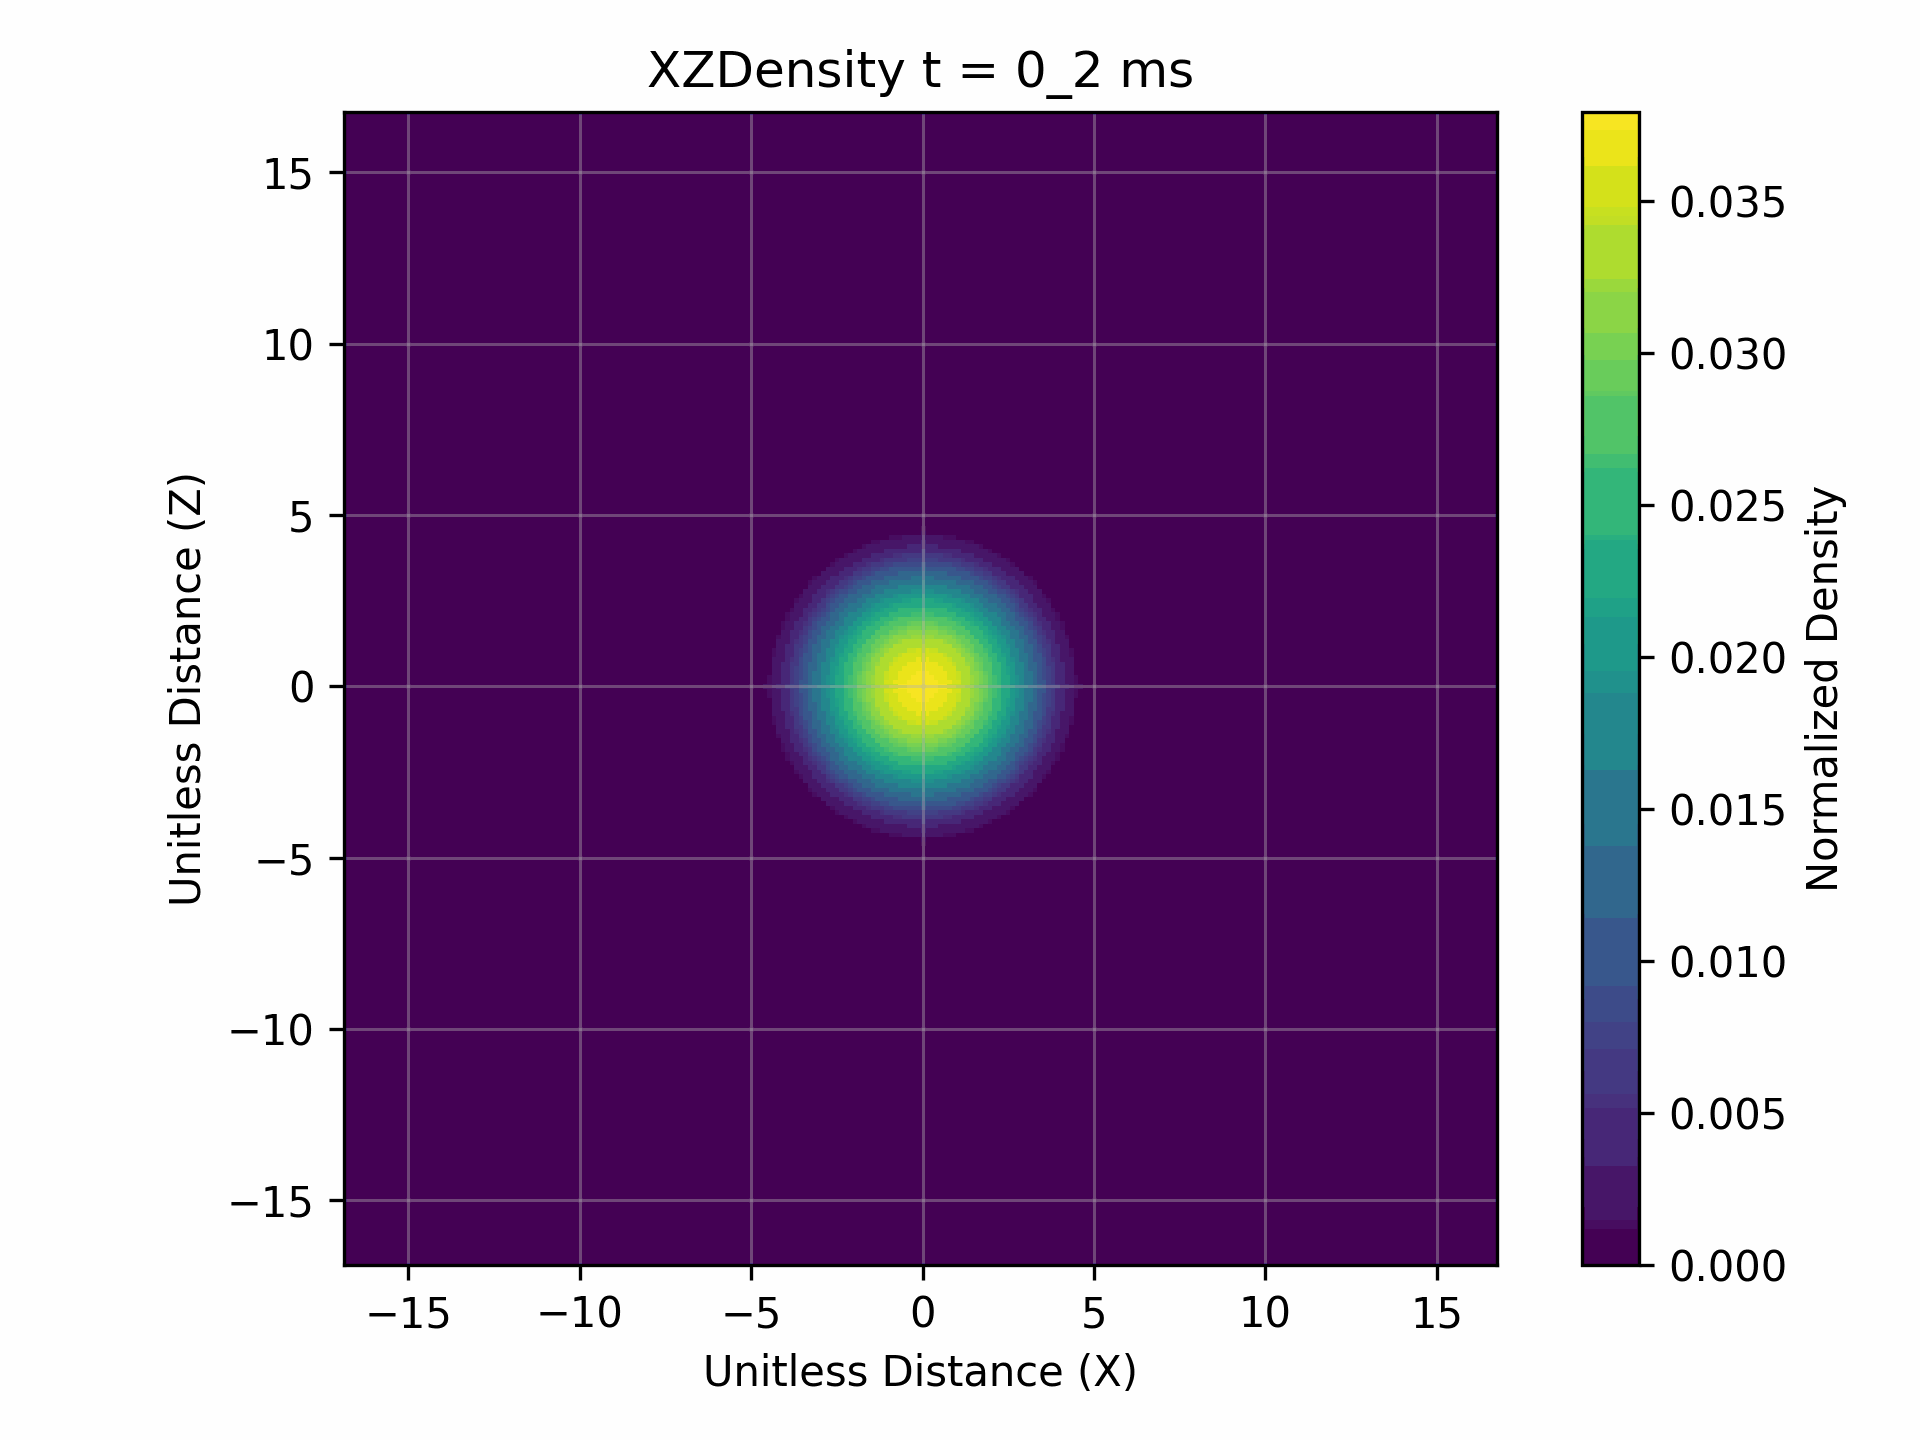

  Stitching 100 frames in 'Y_Slice'...
  -> Success! Saved Y_Slice.gif
  Stitching 100 frames in 'Z_Slice'...
  -> Success! Saved Z_Slice.gif
  Stitching 100 frames in 'XY_and_Initial_Density'...
  -> Success! Saved XY_and_Initial_Density.gif
  Stitching 100 frames in 'XY_Density'...
  -> Success! Saved XY_Density.gif


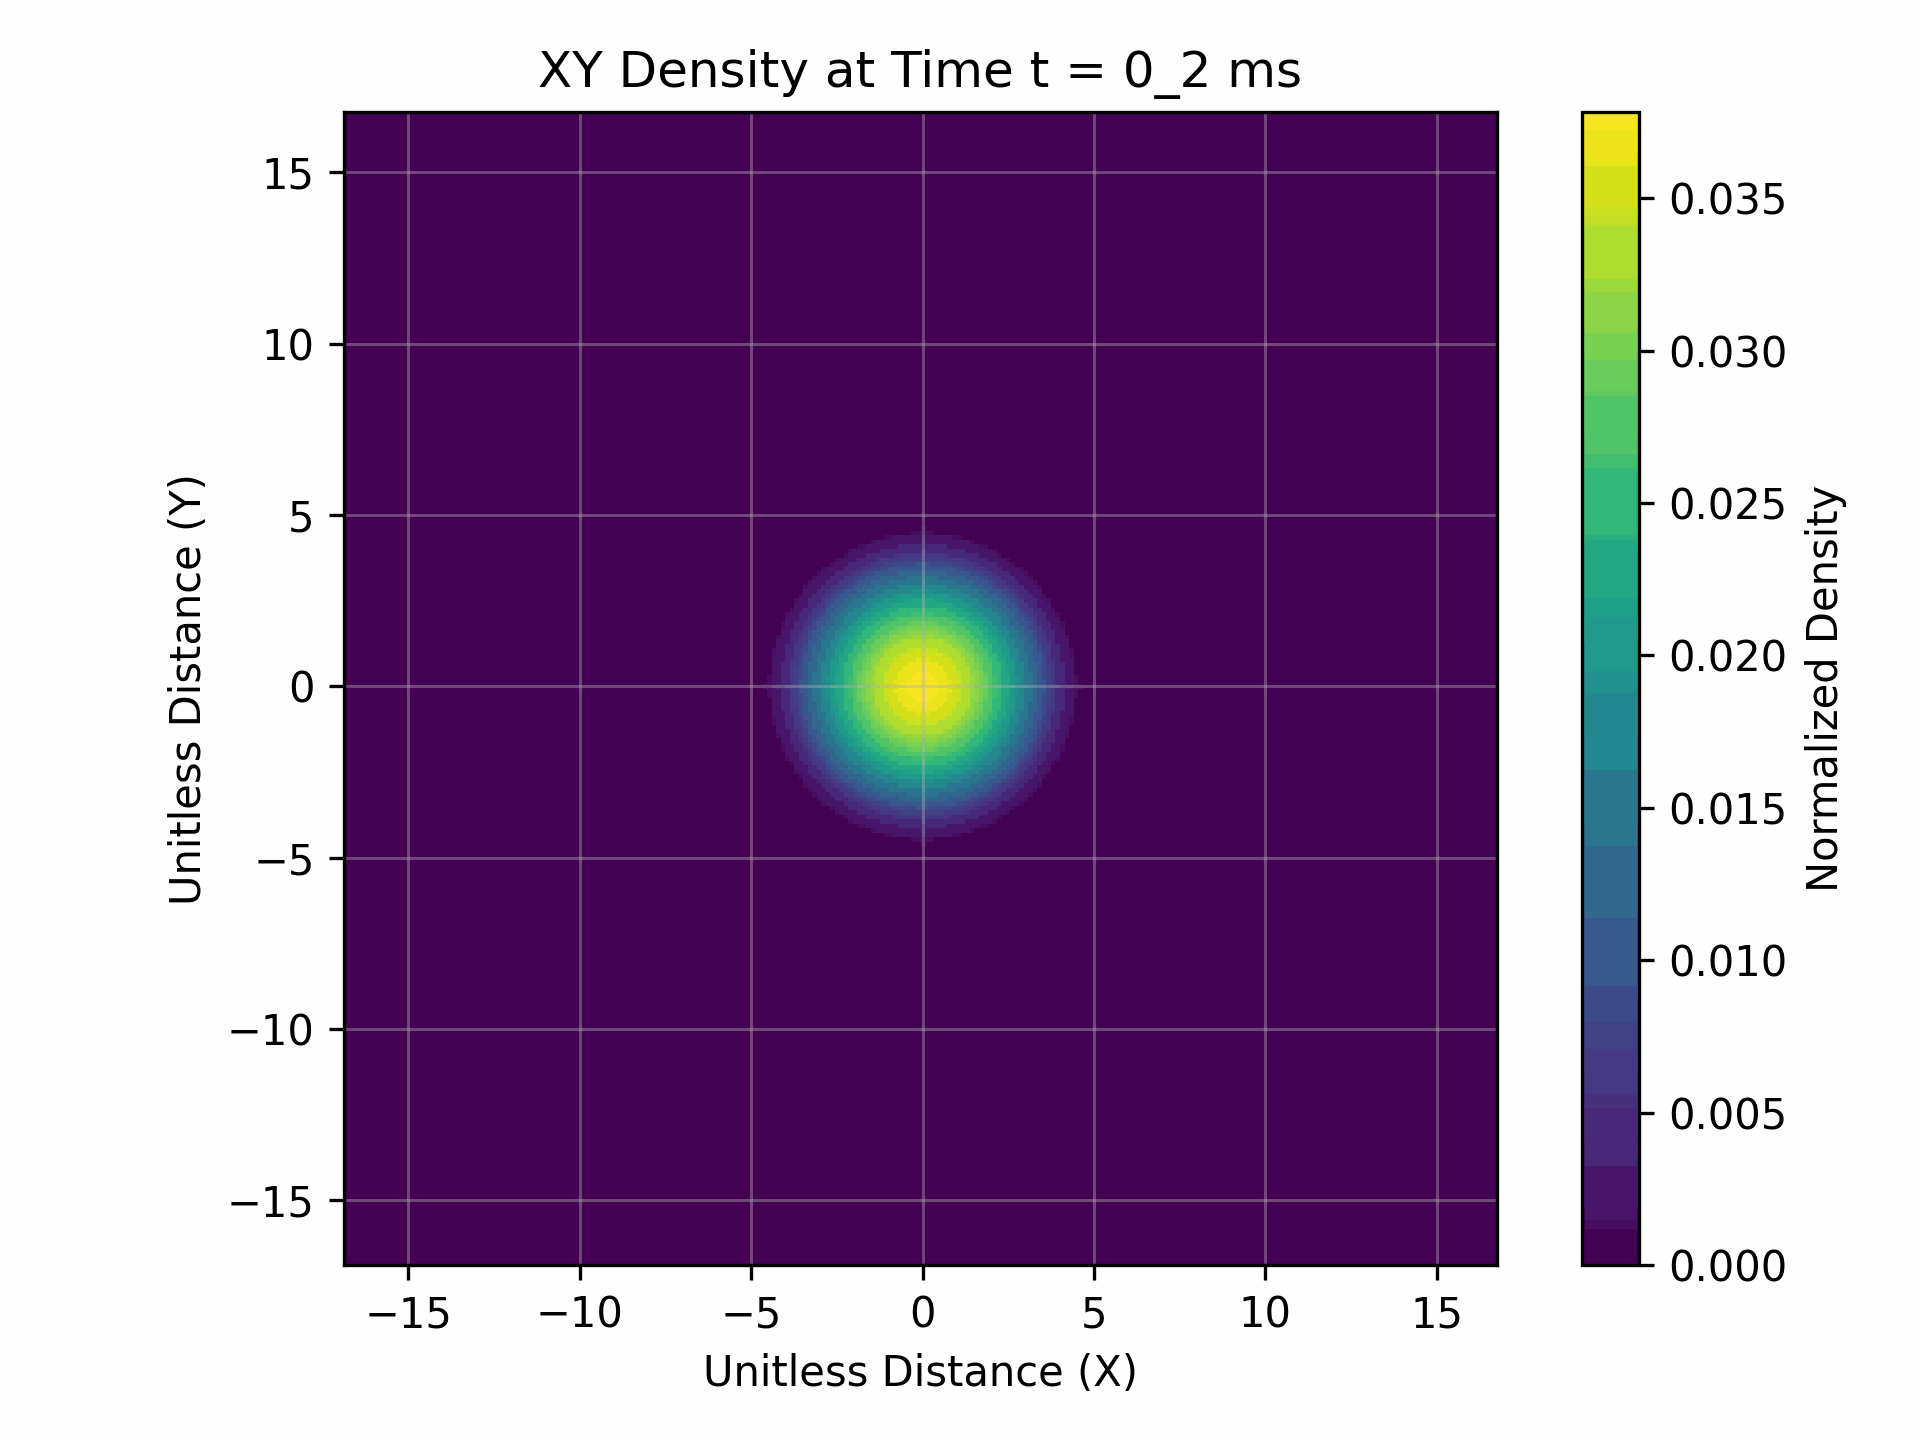

GIF generation complete.
Compressing 'storage/simulation_data_20260814_194920' into storage/simulation_data_20260814_194920_exported.zip...
Mounting Google Drive...
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Success! Copied to Google Drive at: /content/drive/MyDrive/Duke/SimulationData/simulation_data_20260814_194920_exported.zip
Triggering local download...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [5]:
sim.export_plots()

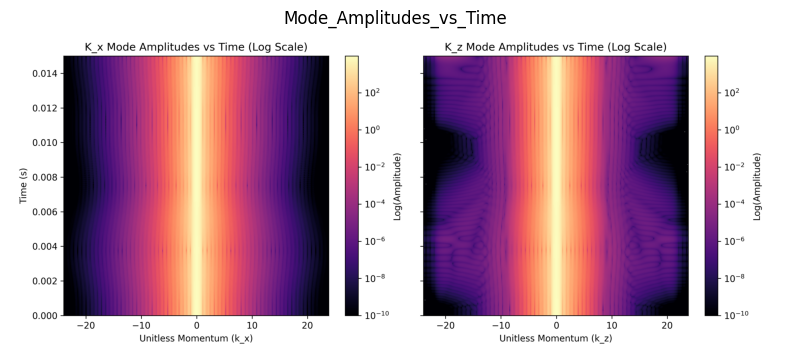

In [6]:
sim.gpe.visualizer.show_plots("Amplitudes")

In [20]:
N, Np, omega = sim.gpe.N, sim.gpe.Np, sim.gpe.omega
filename=f"storage/ground_state_N_{N}_Np_{Np}_omega_{np.round(omega)}_includeg0_{sim.gpe.include_g0}_imag_gamma_{sim.parameters['imag_gamma']}".replace(".", "_") + ".pt"
if os.path.exists(filename):
    print(f"Loading cached ground state from {filename}...")
    ground_state = torch.load(filename, map_location=sim.device)

Loading cached ground state from storage/ground_state_N_256_Np_100000_0_omega_251_0_includeg0_True_imag_gamma_1.pt...


In [5]:
q1 = sim.gpe.quadrupole_term(ground_state) 
g2_energy = 0.5 * torch.sum(q1 * torch.abs(ground_state)**2) * sim.gpe.dxu**2 * sim.gpe.dzu
print(g2_energy.item())

-0.008360926993191242


In [1]:
!ls

sample_data


: 

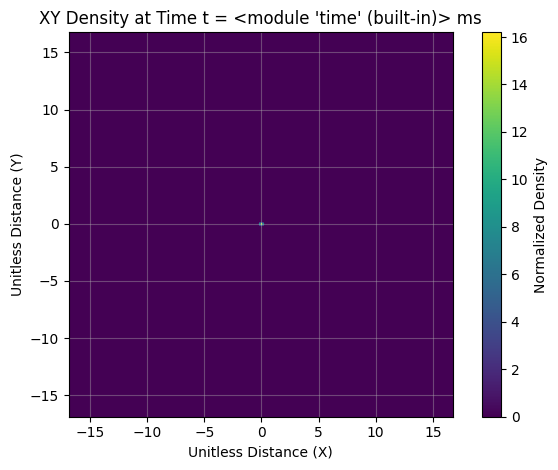

In [21]:
pX1 = sim.gpe.visualizer.pX1
pY = sim.gpe.visualizer.pY
l = sim.gpe.l; dz = sim.gpe.dz; dx = sim.gpe.dx

current_wf = ground_state.cpu().numpy()
uxy_density = np.sum(np.abs(current_wf)**2 * dz/l, axis=2)
uxz_density = np.sum(np.abs(current_wf)**2 * dx/l, axis=1)



fig1, ax1 = plt.subplots()
ax1.set_aspect('equal', 'box')
im1 = ax1.pcolormesh(pX1/l, pY/l, uxy_density)
ax1.set_title(f"XY Density at Time t = {time} ms")
ax1.set_xlabel("Unitless Distance (X)")
ax1.set_ylabel("Unitless Distance (Y)")
fig1.colorbar(im1, ax=ax1, label="Normalized Density")
ax1.grid(True, alpha=0.4)
fig1.tight_layout()
    

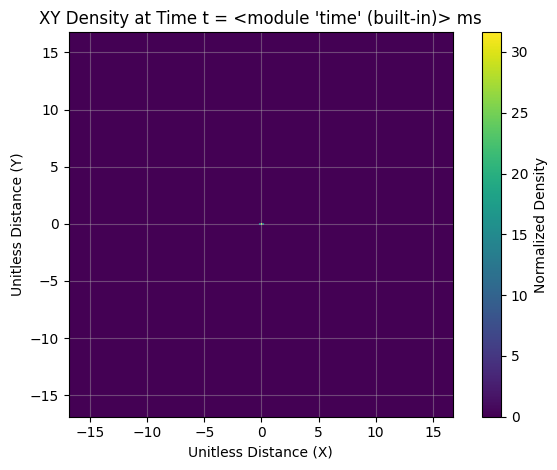

In [22]:
fig1, ax1 = plt.subplots()
ax1.set_aspect('equal', 'box')
im1 = ax1.pcolormesh(pX1/l, pY/l, uxz_density)
ax1.set_title(f"XY Density at Time t = {time} ms")
ax1.set_xlabel("Unitless Distance (X)")
ax1.set_ylabel("Unitless Distance (Y)")
fig1.colorbar(im1, ax=ax1, label="Normalized Density")
ax1.grid(True, alpha=0.4)
fig1.tight_layout()

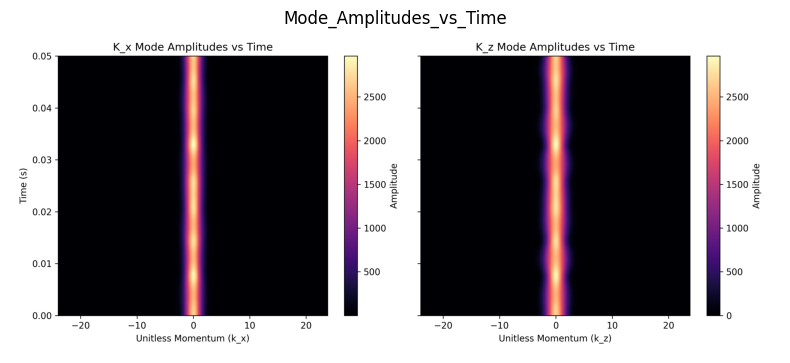

In [8]:
sim.gpe.visualizer.show_plots("Amplitudes")

In [7]:
torch.Tensor([0]).item()

0.0